In [1]:
import sys; sys.path.append("..")
import pandas as pd
from src.data_pipeline.stock_data import load_prices

df= load_prices(["TSLA"]).sort_values("date").set_index("date")
df.index = pd.to_datetime(df.index)

ret = df["close"].pct_change()
print(ret.tail())


date
2026-07-14    0.003597
2026-07-15   -0.004341
2026-07-16   -0.008619
2026-07-17   -0.026134
2026-07-20   -0.029592
Name: close, dtype: float64


In [3]:
lags = pd.DataFrame({"ret_1d": df["close"].pct_change(),
                     "ret_5d": df["close"].pct_change(5),
                     "ret_10d": df["close"].pct_change(10)})
lags.tail()

,ret_1d,ret_5d,ret_10d
date,,,
2026-07-14,0.003597,-0.016679,-0.038024
2026-07-15,-0.004341,0.001015,-0.062149
2026-07-16,-0.008619,-0.038101,-0.080508
2026-07-17,-0.026134,-0.066019,-0.032050
2026-07-20,-0.029592,-0.063811,-0.119589


<Axes: title={'center': 'TSLA RSI(14)'}, xlabel='date'>

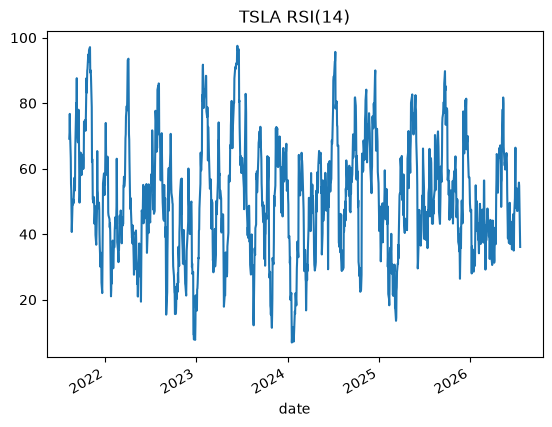

In [4]:
def compute_rsi(close, window=14):
    delta = close.diff()                      # each day's move
    gain = delta.clip(lower=0)                # keep only up-moves (down-days become 0)
    loss = -delta.clip(upper=0)               # keep only down-moves, made positive
    avg_gain = gain.rolling(window).mean()    # average up-pull, last 14 days
    avg_loss = loss.rolling(window).mean()    # average down-pull, last 14 days
    rs = avg_gain / avg_loss                  # the tug-of-war ratio
    return 100 - 100 / (1 + rs)               # squash it into 0–100

rsi = compute_rsi(df["close"])
rsi.plot(title="TSLA RSI(14)")

<Axes: title={'center': 'TSLA MACD (normalized)'}, xlabel='date'>

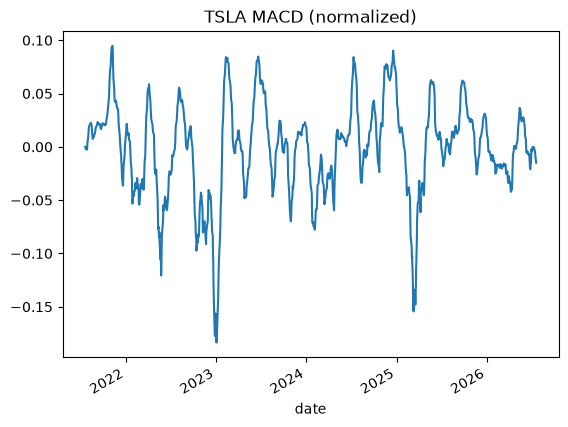

In [5]:
def compute_macd(close):
    ema12 = close.ewm(span=12, adjust=False).mean()   # the sprinter
    ema26 = close.ewm(span=26, adjust=False).mean()   # the jogger
    return (ema12 - ema26) / close                     # the gap, as a % of price

compute_macd(df["close"]).plot(title="TSLA MACD (normalized)")

In [6]:
import sys; sys.path.append("..")
import pandas as pd

feats = pd.read_parquet("../data/processed/features/TSLA.parquet")

train = feats[feats.index < "2024-01-01"]
val   = feats[(feats.index >= "2024-01-01") & (feats.index < "2025-01-01")]
test  = feats[feats.index >= "2025-01-01"]
print(f"train: {len(train)} rows (ends {train.index.max().date()})")
print(f"val:   {len(val)} rows")
print(f"test:  {len(test)} rows (starts {test.index.min().date()})")

train: 567 rows (ends 2023-12-29)
val:   252 rows
test:  381 rows (starts 2025-01-02)


In [7]:
for t in ["TSLA", "NVDA", "JNJ", "XOM"]:
    f = pd.read_parquet(f"../data/processed/features/{t}.parquet")
    print(f"{t}: up-days {f['target_1d'].mean():.3f} | 5-day-up {f['target_5d'].mean():.3f}")

TSLA: up-days 0.515 | 5-day-up 0.478
NVDA: up-days 0.535 | 5-day-up 0.578
JNJ: up-days 0.516 | 5-day-up 0.516
XOM: up-days 0.539 | 5-day-up 0.568


## Split policy
Chronological, never shuffled: train ≤ 2023 · validation = 2024 · test = 2025+.
The model studies the past, is tuned on the recent past, and is judged on a
future it has never seen — shuffling would leak future rows into training.

## Leakage checklist — every feature looks only backward
- ret_1d/2d/3d/5d/10d — pct_change over PAST days only ✅
- price_vs_ma20, ma20_vs_ma50 — rolling means of PAST 20/50 days ✅
- vol_20d — std of PAST 20 daily returns ✅
- rsi_14 — diff + rolling means over PAST 14 days ✅
- macd — EMAs decay over PAST prices only ✅
- volume_z — PAST 20-day volume mean/std ✅
- target_1d / target_5d — shift(-1)/shift(-5): INTENTIONALLY future; labels only,
  never features; rows without a real future are dropped, not faked ✅
- Split — chronological; no shuffling ✅
- Scaling — none yet; when Week 2 models need it, the scaler will be fit on
  TRAIN rows only ✅ (note to future self)